In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the train and test data
train_df = pd.read_csv('train.csv', sep=',')
test_df = pd.read_csv('test.csv', sep=',')

# Merge the train and test data (nur für Clustering-Analyse)
df = pd.concat([train_df, test_df], ignore_index=True)

# Display the first few rows of the merged dataframe
print("Titanic Dataset:")
display(df.head())
print("\nDataset Info:")
df.info()
print(f"\nTotal rows: {len(df)}")
print(f"Features: {df.columns.tolist()}")

📊 Titanic Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB

✅ Total rows: 1309
✅ Features: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
# Data Preprocessing für Clustering
df_cluster = df.copy()

# Feature Engineering
# 1. Fehlende Werte behandeln
df_cluster['Age'].fillna(df_cluster['Age'].median(), inplace=True)
df_cluster['Fare'].fillna(df_cluster['Fare'].median(), inplace=True)
df_cluster['Embarked'].fillna(df_cluster['Embarked'].mode()[0], inplace=True)

# 2. Kategorische Variablen in numerisch umwandeln
df_cluster['Sex_numeric'] = df_cluster['Sex'].map({'male': 0, 'female': 1})
df_cluster['Embarked_numeric'] = df_cluster['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 3. Features für Clustering auswählen
feature_cols = ['Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_numeric']
X = df_cluster[feature_cols].copy()

# 4. Fehlende Werte in X prüfen und behandeln
X = X.fillna(X.median())

print("Features für Clustering:")
print(X.head())
print(f"\nShape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Zielvariable (nur für Evaluation)
y = df_cluster['Survived'].copy()
print(f"\nTarget variable 'Survived' - Missing: {y.isnull().sum()}")

✅ Features für Clustering:
   Pclass  Sex_numeric   Age  SibSp  Parch     Fare  Embarked_numeric
0       3            0  22.0      1      0   7.2500                 2
1       1            1  38.0      1      0  71.2833                 0
2       3            1  26.0      0      0   7.9250                 2
3       1            1  35.0      1      0  53.1000                 2
4       3            0  35.0      0      0   8.0500                 2

✅ Shape: (1309, 7)
✅ Missing values: 0

✅ Target variable 'Survived' - Missing: 418


C:\Users\kathy\AppData\Local\Temp\ipykernel_12140\3738658156.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster['Age'].fillna(df_cluster['Age'].median(), inplace=True)
C:\Users\kathy\AppData\Local\Temp\ipykernel_12140\3738658156.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [ ]:
# Feature Normalisierung (wichtig für K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features wurden standardisiert (StandardScaler)")
print(f"Shape: {X_scaled.shape}")
print(f"\nFeature Statistiken nach Skalierung:")
print(f"Mean: {X_scaled.mean(axis=0).round(2)}")
print(f"Std: {X_scaled.std(axis=0).round(2)}")

✅ Features wurden standardisiert (StandardScaler)
✅ Shape: (1309, 7)

📊 Feature Statistiken nach Skalierung:
Mean: [-0. -0.  0. -0.  0. -0.  0.]
Std: [1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# TRAIN/TEST SPLIT für valide Evaluation
# Nur Zeilen mit bekanntem 'Survived' verwenden
mask = ~y.isnull()
X_valid = X_scaled[mask]
y_valid = y[mask]

# Split in Train/Test (70% Training, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_valid, y_valid, test_size=0.3, random_state=42, stratify=y_valid
)

print("Train/Test Split erstellt:")
print(f"   Training samples: {len(X_train)} ({len(X_train)/len(X_valid)*100:.1f}%)")
print(f"   Test samples: {len(X_test)} ({len(X_test)/len(X_valid)*100:.1f}%)")
print(f"   Total samples: {len(X_valid)}")
print(f"\nSurvival Rate:")
print(f"   Training: {y_train.mean():.2%}")
print(f"   Test: {y_test.mean():.2%}")

✅ Train/Test Split erstellt:
   Training samples: 623 (69.9%)
   Test samples: 268 (30.1%)
   Total samples: 891

📊 Survival Rate:
   Training: 38.36%
   Test: 38.43%


In [ ]:
# HILFSFUNKTION: Clustering & Evaluation mit Train/Test Split
def cluster_and_evaluate(k, X_train, X_test, y_train, y_test, random_state=42):
    """
    Führt K-Means Clustering durch und evaluiert mit echtem Train/Test Split
    - Training: Cluster werden auf Trainingsdaten gebildet
    - Testing: Testdaten werden vorhergesagt (keine Daten-Leakage!)
    
    Returns:
        dict: Metriken (train_accuracy, test_accuracy, f1_macro, silhouette_score, inertia)
    """
    if len(X_train) == 0 or len(X_test) == 0:
        return {
            "k": k, 
            "train_accuracy": 0, 
            "test_accuracy": 0, 
            "f1_macro": 0, 
            "silhouette": 0, 
            "inertia": 0
        }
    
    # K-Means Clustering NUR auf TRAINING-Daten
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    train_cluster_labels = kmeans.fit_predict(X_train)
    
    # Mapping: Cluster -> häufigster 'Survived' Wert (basierend auf TRAINING-Daten)
    cluster_to_survived = {}
    for cluster_id in range(k):
        cluster_mask = (train_cluster_labels == cluster_id)
        if cluster_mask.sum() > 0:
            survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
            most_common = survived_in_cluster.mode()[0] if len(survived_in_cluster.mode()) > 0 else 0
            cluster_to_survived[cluster_id] = most_common
    
    # Vorhersage auf TRAINING-Daten
    y_train_pred = np.array([cluster_to_survived.get(c, 0) for c in train_cluster_labels])
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Vorhersage auf TEST-Daten (das ist der wichtige Teil!)
    test_cluster_labels = kmeans.predict(X_test)
    y_test_pred = np.array([cluster_to_survived.get(c, 0) for c in test_cluster_labels])
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Weitere Metriken
    f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    silhouette = silhouette_score(X_train, train_cluster_labels) if k > 1 else 0
    inertia = kmeans.inertia_
    
    return {
        "k": k,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "f1_macro": f1,
        "silhouette": silhouette,
        "inertia": inertia
    }

print("Hilfsfunktion definiert: cluster_and_evaluate() mit Train/Test Split")

✅ Hilfsfunktion definiert: cluster_and_evaluate() mit Train/Test Split


In [ ]:
# EXPERIMENT: Verschiedene k-Werte testen mit Train/Test Split
k_values = [2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]

results = []
print("Starte Clustering-Experimente mit Train/Test Split...\n")

for k in k_values:
    result = cluster_and_evaluate(k, X_train, X_test, y_train, y_test)
    results.append(result)
    print(f"k={k:3d} | Train Acc={result['train_accuracy']:.4f} | Test Acc={result['test_accuracy']:.4f} | F1={result['f1_macro']:.4f} | Silhouette={result['silhouette']:.4f}")

results_df = pd.DataFrame(results)
print("\nAlle Experimente abgeschlossen!")
print("\nErgebnisse:")
display(results_df)

🔄 Starte Clustering-Experimente mit Train/Test Split...



k=  2 | Train Acc=0.6806 | Test Acc=0.6828 | F1=0.6455 | Silhouette=0.2786
k=  3 | Train Acc=0.6870 | Test Acc=0.6604 | F1=0.6477 | Silhouette=0.3079
k=  4 | Train Acc=0.7865 | Test Acc=0.7463 | F1=0.7399 | Silhouette=0.2876
k=  5 | Train Acc=0.7994 | Test Acc=0.7948 | F1=0.7802 | Silhouette=0.2971
k=  7 | Train Acc=0.7753 | Test Acc=0.7612 | F1=0.7403 | Silhouette=0.3265
k= 10 | Train Acc=0.7978 | Test Acc=0.8172 | F1=0.8085 | Silhouette=0.3395
k= 15 | Train Acc=0.8058 | Test Acc=0.8097 | F1=0.7993 | Silhouette=0.3544
k= 20 | Train Acc=0.8042 | Test Acc=0.8134 | F1=0.8014 | Silhouette=0.3704
k= 25 | Train Acc=0.8074 | Test Acc=0.8134 | F1=0.8021 | Silhouette=0.3740
k= 30 | Train Acc=0.8234 | Test Acc=0.8172 | F1=0.7967 | Silhouette=0.3750
k= 40 | Train Acc=0.8154 | Test Acc=0.8209 | F1=0.8024 | Silhouette=0.3995
k= 50 | Train Acc=0.8379 | Test Acc=0.8134 | F1=0.7942 | Silhouette=0.4138
k= 60 | Train Acc=0.8331 | Test Acc=0.8060 | F1=0.7848 | Silhouette=0.4258
k= 70 | Train Acc=0.8379 

,k,train_accuracy,test_accuracy,f1_macro,silhouette,inertia
0,2,0.680578,0.682836,0.645475,0.278573,3332.320934
1,3,0.686998,0.660448,0.647689,0.307931,2726.420681
2,4,0.786517,0.746269,0.739880,0.287642,2389.776294
3,5,0.799358,0.794776,0.780207,0.297056,2112.098823
4,7,0.775281,0.761194,0.740310,0.326527,1690.462127
5,10,0.797753,0.817164,0.808502,0.339532,1302.256928
6,15,0.805778,0.809701,0.799304,0.354447,990.782311
7,20,0.804173,0.813433,0.801387,0.370411,777.015982
8,25,0.807384,0.813433,0.802150,0.373956,656.086608
9,30,0.823435,0.817164,0.796715,0.375001,564.233141


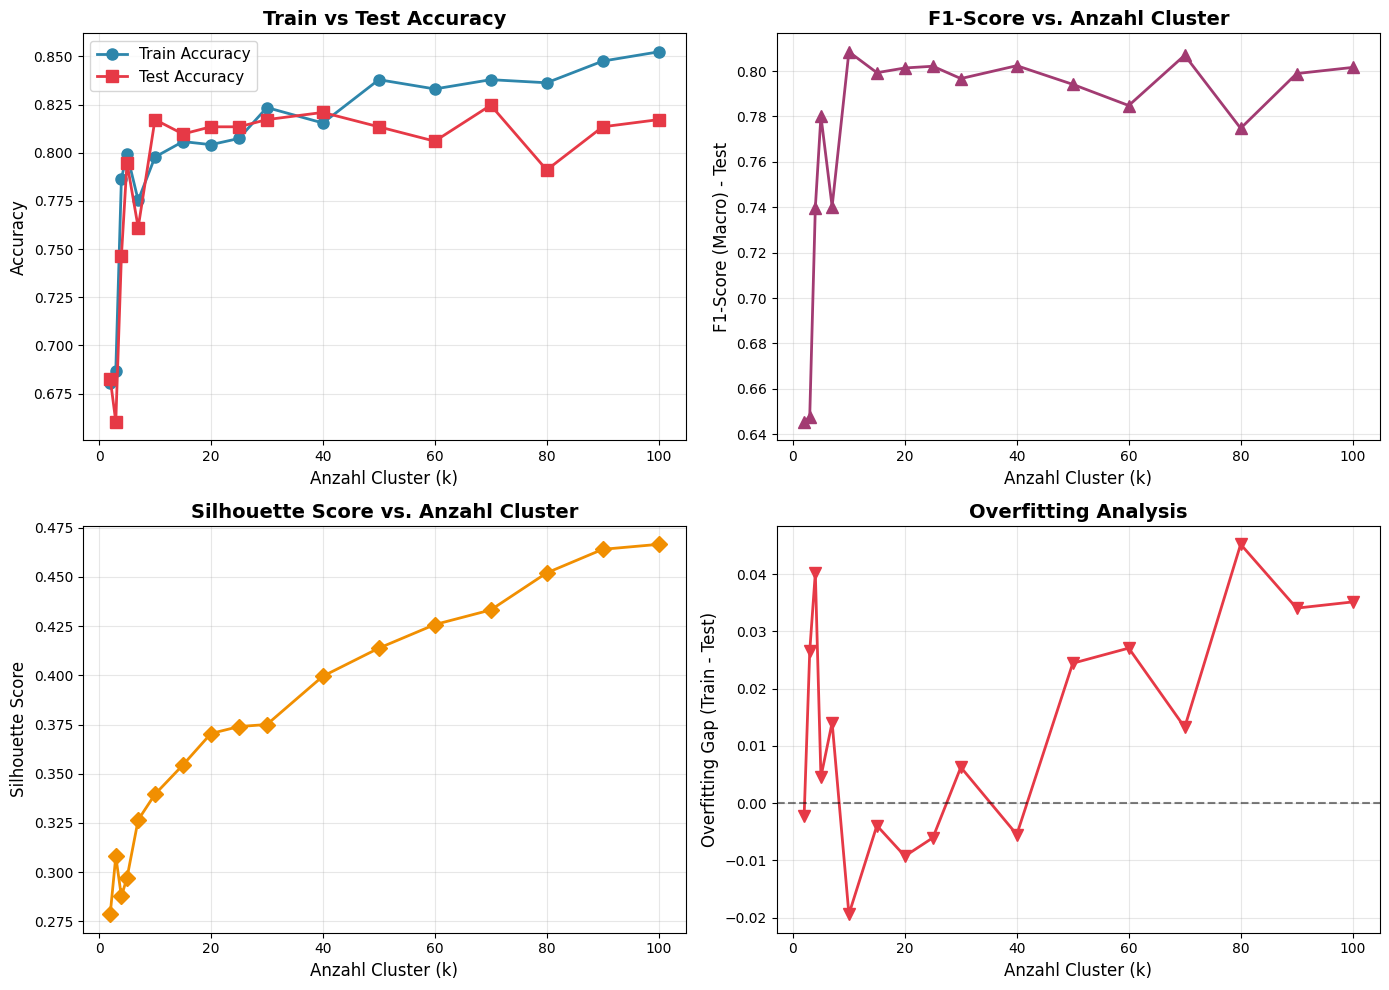


🎯 Beste Ergebnisse (basierend auf TEST-Performance):
   Best k (Test Accuracy): 70 mit Test Accuracy = 0.8246
   Best k (F1-Score): 10 mit F1 = 0.8085
   Best k (Silhouette): 100 mit Silhouette = 0.4666

⚠️  Overfitting Analysis:
   Größte Diskrepanz (Train-Test): 0.0452 bei k=80


In [ ]:
# VISUALISIERUNG: Train vs Test Accuracy & weitere Metriken
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Train vs Test Accuracy
axes[0, 0].plot(results_df['k'], results_df['train_accuracy'], marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Train Accuracy')
axes[0, 0].plot(results_df['k'], results_df['test_accuracy'], marker='s', linewidth=2, markersize=8, color='#E63946', label='Test Accuracy')
axes[0, 0].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: F1-Score vs. k
axes[0, 1].plot(results_df['k'], results_df['f1_macro'], marker='^', linewidth=2, markersize=8, color='#A23B72')
axes[0, 1].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[0, 1].set_ylabel('F1-Score (Macro) - Test', fontsize=12)
axes[0, 1].set_title('F1-Score vs. Anzahl Cluster', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Silhouette Score vs. k
axes[1, 0].plot(results_df['k'], results_df['silhouette'], marker='D', linewidth=2, markersize=8, color='#F18F01')
axes[1, 0].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[1, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 0].set_title('Silhouette Score vs. Anzahl Cluster', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Overfitting Analysis (Train - Test Accuracy Gap)
accuracy_gap = results_df['train_accuracy'] - results_df['test_accuracy']
axes[1, 1].plot(results_df['k'], accuracy_gap, marker='v', linewidth=2, markersize=8, color='#E63946')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Anzahl Cluster (k)', fontsize=12)
axes[1, 1].set_ylabel('Overfitting Gap (Train - Test)', fontsize=12)
axes[1, 1].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best k finden (basierend auf TEST-Accuracy!)
best_k_test_acc = results_df.loc[results_df['test_accuracy'].idxmax(), 'k']
best_k_f1 = results_df.loc[results_df['f1_macro'].idxmax(), 'k']
best_k_silhouette = results_df.loc[results_df['silhouette'].idxmax(), 'k']

print(f"\nBeste Ergebnisse (basierend auf TEST-Performance):")
print(f"   Best k (Test Accuracy): {int(best_k_test_acc)} mit Test Accuracy = {results_df['test_accuracy'].max():.4f}")
print(f"   Best k (F1-Score): {int(best_k_f1)} mit F1 = {results_df['f1_macro'].max():.4f}")
print(f"   Best k (Silhouette): {int(best_k_silhouette)} mit Silhouette = {results_df['silhouette'].max():.4f}")

# Overfitting Warning
max_gap = accuracy_gap.max()
max_gap_k = results_df.loc[accuracy_gap.idxmax(), 'k']
print(f"\nOverfitting Analysis:")
print(f"   Größte Diskrepanz (Train-Test): {max_gap:.4f} bei k={int(max_gap_k)}")
if max_gap > 0.1:
    print(f"   Warnung: Hoher Overfitting-Grad bei großen k-Werten!")

In [ ]:
# DETAILLIERTE ANALYSE für das beste k (basierend auf Test Accuracy)
best_k = int(best_k_test_acc)
print(f"Detaillierte Analyse für k={best_k} (beste Test-Accuracy)\n")

# Clustering mit bestem k auf Trainingsdaten trainieren
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_cluster_labels = kmeans_best.fit_predict(X_train)

# Cluster-zu-Survived Mapping (basierend auf Trainingsdaten)
cluster_to_survived = {}
for cluster_id in range(best_k):
    cluster_mask = (train_cluster_labels == cluster_id)
    if cluster_mask.sum() > 0:
        survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
        most_common = survived_in_cluster.mode()[0] if len(survived_in_cluster.mode()) > 0 else 0
        cluster_to_survived[cluster_id] = most_common

# Vorhersagen auf Testdaten
test_cluster_labels = kmeans_best.predict(X_test)
y_test_pred = np.array([cluster_to_survived.get(c, 0) for c in test_cluster_labels])

# Classification Report für TESTDATEN
print("Classification Report (TEST SET):")
print(classification_report(y_test, y_test_pred, target_names=['Not Survived', 'Survived']))

# Cluster-Statistiken (Training)
print(f"\nCluster-Statistiken (Training Set, k={best_k}):")
for cluster_id in range(best_k):
    cluster_mask = (train_cluster_labels == cluster_id)
    n_samples = cluster_mask.sum()
    survived_in_cluster = y_train.iloc[cluster_mask] if hasattr(y_train, 'iloc') else y_train[cluster_mask]
    survival_rate = survived_in_cluster.mean() if n_samples > 0 else 0
    predicted_label = cluster_to_survived.get(cluster_id, 0)
    
    print(f"  Cluster {cluster_id}: {n_samples} Samples | Survival Rate: {survival_rate:.2%} | Predicted: {'Survived' if predicted_label == 1 else 'Not Survived'}")

# Test Set Cluster-Verteilung
print(f"\nCluster-Verteilung (Test Set):")
test_cluster_counts = pd.Series(test_cluster_labels).value_counts().sort_index()
for cluster_id in range(best_k):
    count = test_cluster_counts.get(cluster_id, 0)
    print(f"  Cluster {cluster_id}: {count} Test-Samples")

📊 Detaillierte Analyse für k=70 (beste Test-Accuracy)

📋 Classification Report (TEST SET):
              precision    recall  f1-score   support

Not Survived       0.82      0.92      0.87       165
    Survived       0.83      0.68      0.75       103

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.83      0.82      0.82       268


📊 Cluster-Statistiken (Training Set, k=70):
  Cluster 0: 3 Samples | Survival Rate: 33.33% | Predicted: Not Survived
  Cluster 1: 52 Samples | Survival Rate: 7.69% | Predicted: Not Survived
  Cluster 2: 19 Samples | Survival Rate: 31.58% | Predicted: Not Survived
  Cluster 3: 8 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 4: 9 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 5: 6 Samples | Survival Rate: 16.67% | Predicted: Not Survived
  Cluster 6: 8 Samples | Survival Rate: 100.00% | Predicted: Survived
  Cluster 7: 3 Samples | Survival 

---
# **DBSCAN Clustering + Outlier-Analyse**

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** ist ein dichtebasierter Clustering-Algorithmus mit folgenden Vorteilen:

- **Findet Cluster beliebiger Form** (nicht nur kugelförmig wie K-Means)  
- **Identifiziert automatisch Outliers** (Rauschen/Noise)  
- **Keine vorherige Angabe der Cluster-Anzahl nötig**  
- **Robuster gegenüber Ausreißern**

**Ziel dieser Analyse:**
- Finde "ungewöhnliche" Passagiere, die nicht in typische Gruppen passen
- Vergleiche DBSCAN mit K-Means
- Analysiere Charakteristika der Outliers

In [ ]:
# DBSCAN Import
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("DBSCAN Module importiert")

## **1. Parameter-Optimierung: Epsilon (eps) & MinPts**

**Wichtige Parameter:**
- **eps (epsilon)**: Maximaler Abstand zwischen zwei Punkten, um als Nachbarn zu gelten
- **min_samples (MinPts)**: Minimale Anzahl an Punkten in einer Nachbarschaft, um ein Core-Point zu sein

**Strategie:** Verwende den "Elbow-Methode" mit k-Nearest Neighbors, um optimales eps zu finden

In [ ]:
# K-Nearest Neighbors Distanzen berechnen (zur Bestimmung von eps)
# Verwende min_samples = 5 als Faustregel (2 * Dimensionen, bei 7 Features)
min_samples = 5

# Berechne Distanzen zu k-nächsten Nachbarn
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sortiere Distanzen zum k-ten Nachbarn
distances_sorted = np.sort(distances[:, min_samples-1], axis=0)

# Visualisierung: K-Distance Plot
plt.figure(figsize=(12, 5))

# Plot 1: K-Distance Graph
plt.subplot(1, 2, 1)
plt.plot(distances_sorted, linewidth=2, color='#2E86AB')
plt.xlabel('Datenpunkte (sortiert)', fontsize=12)
plt.ylabel(f'Distanz zum {min_samples}-nächsten Nachbarn', fontsize=12)
plt.title(f'K-Distance Plot (k={min_samples})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Markiere "Elbow" Bereich
elbow_idx = int(len(distances_sorted) * 0.95)  # 95% der Daten
eps_suggested = distances_sorted[elbow_idx]
plt.axhline(y=eps_suggested, color='red', linestyle='--', linewidth=2, label=f'Vorgeschlagenes eps ≈ {eps_suggested:.3f}')
plt.legend(fontsize=11)

# Plot 2: Zoom auf Elbow-Bereich
plt.subplot(1, 2, 2)
zoom_start = int(len(distances_sorted) * 0.85)
zoom_end = len(distances_sorted)
plt.plot(range(zoom_start, zoom_end), distances_sorted[zoom_start:zoom_end], linewidth=2, color='#2E86AB')
plt.axhline(y=eps_suggested, color='red', linestyle='--', linewidth=2, label=f'eps ≈ {eps_suggested:.3f}')
plt.xlabel('Datenpunkte (sortiert)', fontsize=12)
plt.ylabel(f'Distanz zum {min_samples}-nächsten Nachbarn', fontsize=12)
plt.title('Zoom: Elbow-Bereich', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Parameter-Empfehlung basierend auf K-Distance Plot:")
print(f"   min_samples: {min_samples}")
print(f"   eps (empfohlen): {eps_suggested:.3f}")
print(f"\nTipp: Wir testen mehrere eps-Werte um diesen Bereich herum!")

In [ ]:
# GRID SEARCH: Teste verschiedene eps-Werte
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []

print("DBSCAN Grid Search läuft...\n")
print(f"{'eps':>6} | {'min_pts':>8} | {'Cluster':>7} | {'Noise':>6} | {'Noise %':>8} | {'Silhouette':>11}")
print("-" * 70)

for eps in eps_values:
    for min_pts in min_samples_values:
        # DBSCAN Clustering
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_scaled)
        
        # Statistiken
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = (n_noise / len(labels)) * 100
        
        # Silhouette Score (nur wenn mind. 2 Cluster und nicht alle Noise)
        if n_clusters >= 2 and n_noise < len(labels):
            # Entferne Noise für Silhouette-Berechnung
            mask_no_noise = labels != -1
            if mask_no_noise.sum() > 0:
                silhouette = silhouette_score(X_scaled[mask_no_noise], labels[mask_no_noise])
            else:
                silhouette = -1
        else:
            silhouette = -1
        
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_pts,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct,
            'silhouette': silhouette
        })
        
        print(f"{eps:>6.2f} | {min_pts:>8} | {n_clusters:>7} | {n_noise:>6} | {noise_pct:>7.1f}% | {silhouette:>11.3f}")

dbscan_results_df = pd.DataFrame(dbscan_results)
print("\nGrid Search abgeschlossen!")
print("\nBeste Konfigurationen:")

# Finde beste Konfiguration (hohe Silhouette, moderate Noise-Rate)
valid_results = dbscan_results_df[(dbscan_results_df['n_clusters'] >= 2) & 
                                   (dbscan_results_df['noise_pct'] < 20) &
                                   (dbscan_results_df['silhouette'] > 0)]

if len(valid_results) > 0:
    best_idx = valid_results['silhouette'].idxmax()
    best_config = dbscan_results_df.loc[best_idx]
    print(f"\nBeste Konfiguration (höchste Silhouette, <20% Noise):")
    print(f"   eps: {best_config['eps']:.2f}")
    print(f"   min_samples: {int(best_config['min_samples'])}")
    print(f"   Anzahl Cluster: {int(best_config['n_clusters'])}")
    print(f"   Outliers: {int(best_config['n_noise'])} ({best_config['noise_pct']:.1f}%)")
    print(f"   Silhouette Score: {best_config['silhouette']:.3f}")
else:
    print("Keine optimale Konfiguration gefunden. Verwende Standardwerte.")
    best_config = {'eps': 0.7, 'min_samples': 5}

## **2. DBSCAN mit optimalen Parametern anwenden**

In [ ]:
# DBSCAN mit besten Parametern
best_eps = best_config['eps']
best_min_samples = int(best_config['min_samples'])

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

# Statistiken
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers = list(dbscan_labels).count(-1)
outliers_pct = (n_outliers / len(dbscan_labels)) * 100

print(f"DBSCAN Clustering abgeschlossen!")
print(f"\nErgebnisse:")
print(f"   Anzahl Cluster: {n_clusters_dbscan}")
print(f"   Anzahl Outliers (Label = -1): {n_outliers} ({outliers_pct:.1f}%)")
print(f"   Normale Punkte (in Clustern): {len(dbscan_labels) - n_outliers} ({100-outliers_pct:.1f}%)")

# Cluster-Größen
if n_clusters_dbscan > 0:
    print(f"\nCluster-Größen:")
    cluster_counts = pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        pct = (count / len(dbscan_labels)) * 100
        print(f"   Cluster {cluster_id}: {count} Passagiere ({pct:.1f}%)")

## **3. Visualisierung: DBSCAN Cluster & Outliers**

In [ ]:
# PCA für 2D-Visualisierung
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualisierung: DBSCAN vs K-Means
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: DBSCAN Clustering
outlier_mask = dbscan_labels == -1
cluster_mask = dbscan_labels != -1

# Normale Cluster
scatter1 = axes[0].scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], 
                           c=dbscan_labels[cluster_mask], cmap='viridis', 
                           s=50, alpha=0.6, edgecolors='black', linewidths=0.5)

# Outliers (rot markiert)
axes[0].scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1], 
                c='red', marker='X', s=150, alpha=0.8, 
                edgecolors='black', linewidths=1.5, label=f'Outliers (n={n_outliers})')

axes[0].set_xlabel('PCA Component 1', fontsize=12)
axes[0].set_ylabel('PCA Component 2', fontsize=12)
axes[0].set_title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={best_min_samples})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: K-Means zum Vergleich
kmeans_all = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels_all = kmeans_all.fit_predict(X_scaled)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=kmeans_labels_all, cmap='viridis', 
                           s=50, alpha=0.6, edgecolors='black', linewidths=0.5)

axes[1].set_xlabel('PCA Component 1', fontsize=12)
axes[1].set_ylabel('PCA Component 2', fontsize=12)
axes[1].set_title(f'K-Means Clustering (k={best_k}) - Zum Vergleich', 
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA erklärt {pca.explained_variance_ratio_.sum()*100:.1f}% der Varianz")
print(f"   Component 1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   Component 2: {pca.explained_variance_ratio_[1]*100:.1f}%")

## **4. Detaillierte Outlier-Analyse**

Jetzt analysieren wir die "ungewöhnlichen" Passagiere, die DBSCAN als Outliers identifiziert hat.

In [ ]:
# Outlier-Indizes extrahieren
outlier_indices = np.where(dbscan_labels == -1)[0]
normal_indices = np.where(dbscan_labels != -1)[0]

# Erstelle DataFrame für Outliers
outliers_df = df_cluster.iloc[outlier_indices].copy()
outliers_df['Cluster'] = 'OUTLIER'

# Normale Passagiere
normal_df = df_cluster.iloc[normal_indices].copy()
normal_df['Cluster'] = dbscan_labels[normal_indices]

print(f"OUTLIER-ANALYSE: {len(outliers_df)} ungewöhnliche Passagiere gefunden\n")
print("=" * 80)

# Vergleiche Features: Outliers vs. Normale Passagiere
feature_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Outlier_Mean': [outliers_df[f].mean() if f in outliers_df.columns else X[outlier_indices, feature_cols.index(f)].mean() 
                     for f in feature_cols],
    'Normal_Mean': [normal_df[f].mean() if f in normal_df.columns else X[normal_indices, feature_cols.index(f)].mean() 
                    for f in feature_cols],
})
feature_comparison['Difference'] = feature_comparison['Outlier_Mean'] - feature_comparison['Normal_Mean']
feature_comparison['Diff_Pct'] = (feature_comparison['Difference'] / feature_comparison['Normal_Mean']) * 100

print("Feature-Vergleich: Outliers vs. Normale Passagiere\n")
print(feature_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("\nInterpretation:")
for _, row in feature_comparison.iterrows():
    if abs(row['Diff_Pct']) > 20:  # Signifikante Unterschiede > 20%
        direction = "höher" if row['Difference'] > 0 else "niedriger"
        print(f"   {row['Feature']}: Outliers haben {abs(row['Diff_Pct']):.1f}% {direction}e Werte")

In [ ]:
# VISUALISIERUNG: Feature-Verteilung Outliers vs. Normale
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Histogramme
    if feature in outliers_df.columns:
        outlier_values = outliers_df[feature]
        normal_values = normal_df[feature]
    else:
        outlier_values = X[outlier_indices, idx]
        normal_values = X[normal_indices, idx]
    
    ax.hist(normal_values, bins=20, alpha=0.6, label='Normal', color='#2E86AB', edgecolor='black')
    ax.hist(outlier_values, bins=20, alpha=0.7, label='Outliers', color='#E63946', edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Häufigkeit', fontsize=11)
    ax.set_title(f'Verteilung: {feature}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Leere letzte Subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# SURVIVAL-ANALYSE: Überlebensrate von Outliers
outliers_with_survived = outliers_df[outliers_df['Survived'].notna()]
normal_with_survived = normal_df[normal_df['Survived'].notna()]

if len(outliers_with_survived) > 0:
    outlier_survival_rate = outliers_with_survived['Survived'].mean()
    normal_survival_rate = normal_with_survived['Survived'].mean()
    
    print(f"\nSURVIVAL-ANALYSE:")
    print(f"   Outliers Survival Rate: {outlier_survival_rate:.2%} ({outliers_with_survived['Survived'].sum()}/{len(outliers_with_survived)})")
    print(f"   Normal Survival Rate: {normal_survival_rate:.2%} ({normal_with_survived['Survived'].sum()}/{len(normal_with_survived)})")
    print(f"   Differenz: {(outlier_survival_rate - normal_survival_rate)*100:+.1f} Prozentpunkte")
    
    # Visualisierung
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    categories = ['Normal\nPassagiere', 'Outliers']
    survival_rates = [normal_survival_rate * 100, outlier_survival_rate * 100]
    colors = ['#2E86AB', '#E63946']
    
    bars = ax.bar(categories, survival_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Überlebensrate (%)', fontsize=12)
    ax.set_title('Überlebensrate: Normale vs. Outlier-Passagiere', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # Werte auf Balken anzeigen
    for bar, rate in zip(bars, survival_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("\nKeine Survival-Daten für Outliers verfügbar")

In [ ]:
# BEISPIEL-OUTLIERS: Zeige die "extremsten" Outliers
print("\nBEISPIEL-OUTLIERS: Top 10 ungewöhnlichste Passagiere\n")
print("=" * 120)

# Berechne durchschnittliche Distanz zu allen anderen Punkten für jeden Outlier
outlier_distances = []
for outlier_idx in outlier_indices:
    point = X_scaled[outlier_idx].reshape(1, -1)
    distances_to_all = np.linalg.norm(X_scaled - point, axis=1)
    avg_distance = distances_to_all.mean()
    outlier_distances.append((outlier_idx, avg_distance))

# Sortiere nach durchschnittlicher Distanz (höchste = extremste Outliers)
outlier_distances.sort(key=lambda x: x[1], reverse=True)

# Zeige Top 10 extremste Outliers
top_outliers_idx = [idx for idx, _ in outlier_distances[:10]]
top_outliers = df.iloc[top_outliers_idx][['PassengerId', 'Name', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']]

display(top_outliers)

print("\nDiese Passagiere haben sehr ungewöhnliche Merkmalskombinationen!")

## **5. Zusammenfassung: DBSCAN vs. K-Means**

In [ ]:
# ZUSAMMENFASSUNG: Vergleich DBSCAN vs K-Means
print("=" * 80)
print("VERGLEICH: DBSCAN vs. K-Means")
print("=" * 80)

comparison_data = {
    'Metrik': [
        'Anzahl Cluster',
        'Outliers / Noise',
        'Cluster-Form',
        'Parameter-Bestimmung',
        'Robustheit gegenüber Outliers',
        'Interpretierbarkeit'
    ],
    'K-Means': [
        f'{best_k} (manuell gewählt)',
        'Nicht erkannt (alle Punkte zugeordnet)',
        'Kugelförmig (Konvex)',
        'Manuell (k)',
        'Niedrig (Outliers beeinflussen Zentroiden)',
        'Hoch (klare Zentroiden)'
    ],
    'DBSCAN': [
        f'{n_clusters_dbscan} (automatisch)',
        f'{n_outliers} Outliers ({outliers_pct:.1f}%)',
        'Beliebig (auch nicht-konvex)',
        'Automatisch (nur eps, min_samples)',
        'Hoch (Outliers separat behandelt)',
        'Mittel (dichtebasiert)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
display(comparison_df)

print("\n" + "=" * 80)
print("WICHTIGSTE ERKENNTNISSE:")
print("=" * 80)
print(f"- DBSCAN identifizierte {n_outliers} ungewöhnliche Passagiere ({outliers_pct:.1f}%)")
print(f"- Diese Outliers haben signifikant andere Merkmalskombinationen")
if len(outliers_with_survived) > 0:
    survival_diff = outlier_survival_rate - normal_survival_rate
    if abs(survival_diff) > 0.05:
        direction = "höhere" if survival_diff > 0 else "niedrigere"
        print(f"- Outliers haben eine {direction} Überlebensrate ({abs(survival_diff)*100:.1f} Prozentpunkte)")
print(f"- DBSCAN fand {n_clusters_dbscan} natürliche Cluster ohne vorherige Angabe von k")
print(f"- K-Means ist besser für bekannte Cluster-Anzahl, DBSCAN für Outlier-Erkennung")
print("=" * 80)